In [1]:
# FILE FOR THE GOOD RESULTS


import re
import numpy as np
import matplotlib.pyplot as plt

# File containing the extracted times
file_path = "output_good.txt"

# Variables to store times
sequential_time = None
parallel_times = []

# Regular expressions
seq_pattern = re.compile(r"# elapsed time \(timer_seq_Tot\): ([\d\.]+)s")
par_pattern = re.compile(r"Threads: (\d+), Chunk Size: (\d+)")
par_time_pattern = re.compile(r"# elapsed time \(timer_par_Tot\): ([\d\.]+)s")
scheduling_pattern = re.compile(r"(Static|Dynamic|Guided) scheduling")

# Read and parse the file
with open(file_path, "r") as file:
    lines = file.readlines()
    current_threads = None
    current_chunk = None
    scheduling_type = None

    for line in lines:
        seq_match = seq_pattern.search(line)
        par_match = par_pattern.search(line)
        par_time_match = par_time_pattern.search(line)
        scheduling_match = scheduling_pattern.search(line)

        if seq_match:
            sequential_time = float(seq_match.group(1))

        if par_match:
            current_threads = int(par_match.group(1))
            current_chunk = int(par_match.group(2))

        if scheduling_match:
            scheduling_type = scheduling_match.group(1)

        if par_time_match and current_threads is not None and current_chunk is not None and scheduling_type is not None:
            parallel_time = float(par_time_match.group(1))
            parallel_times.append((current_threads, current_chunk, parallel_time, scheduling_type))

# Compute speedup and save to file
if sequential_time:
    with open("speedup.txt", "w") as output_file:
        output_file.write("Sequential Time: {:.6f} s\n".format(sequential_time))
        output_file.write("Speedup Results:\n")
        output_file.write("Threads | Chunk Size | Parallel Time (s) | Speedup | Scheduling Type\n")
        output_file.write("-" * 70 + "\n")

        for threads, chunk, par_time, scheduling_type in parallel_times:
            speedup = sequential_time / par_time
            output_file.write(f"{threads:7} | {chunk:10} | {par_time:17.6f} | {speedup:7.2f} | {scheduling_type}\n")

    print("Results have been saved to speedup.txt.")
else:
    print("Sequential time not found. Check the input file format.")

# Extract data from parallel_times
chunk_sizes = np.array([entry[1] for entry in parallel_times])
scheduling_types = np.array([entry[3] for entry in parallel_times])
speedups = np.array([sequential_time / entry[2] for entry in parallel_times])
threads_list = np.array([entry[0] for entry in parallel_times])

# Unique chunk sizes
unique_chunk_sizes = np.unique(chunk_sizes)

# Loop over chunk sizes to generate separate plots
for chunk_size in unique_chunk_sizes:
    plt.figure(figsize=(10, 6))

    # Mask for the current chunk size
    mask_chunk = chunk_sizes == chunk_size

    # Data for static and dynamic scheduling
    static_mask = (scheduling_types == 'Static') & mask_chunk
    dynamic_mask = (scheduling_types == 'Dynamic') & mask_chunk

    threads_static = threads_list[static_mask]
    speedups_static = speedups[static_mask]

    threads_dynamic = threads_list[dynamic_mask]
    speedups_dynamic = speedups[dynamic_mask]

    # Theoretical speedup
    theoretical_speedup = np.arange(1, max(threads_list) + 1)

    # Plot static speedup
    plt.plot(threads_static, speedups_static, label='Static Speedup', marker='o')

    # Plot dynamic speedup
    plt.plot(threads_dynamic, speedups_dynamic, label='Dynamic Speedup', marker='o')

    # Plot theoretical speedup
    plt.plot(theoretical_speedup, theoretical_speedup, label='Theoretical Speedup', linestyle='--')

    # Set title and labels
    plt.title(f"Speedup vs Threads for Chunk Size {chunk_size}")
    plt.xlabel("Number of Threads")
    plt.ylabel("Speedup")
    plt.legend()
    plt.grid()

    # Save each graph as a PNG file with chunk size in filename
    plt.savefig(f"GOOD/speedup_chunk_{chunk_size}.png")
    plt.close()

print("Graphs saved as PNG files for each chunk size.")


Results have been saved to speedup.txt.
Graphs saved as PNG files for each chunk size.


In [7]:
# FILE FOR THE BAD RESULTS


import re
import numpy as np
import matplotlib.pyplot as plt

# File containing the extracted times
file_path = "output_bad.txt"

# Variables to store times
sequential_time = None
parallel_times = []

# Regular expressions
seq_pattern = re.compile(r"# elapsed time \(timer_seq_Tot\): ([\d\.]+)s")
par_pattern = re.compile(r"Threads: (\d+), Chunk Size: (\d+)")
par_time_pattern = re.compile(r"# elapsed time \(timer_par_Tot\): ([\d\.]+)s")
scheduling_pattern = re.compile(r"(Static|Dynamic|Guided) scheduling")

# Read and parse the file
with open(file_path, "r") as file:
    lines = file.readlines()
    current_threads = None
    current_chunk = None
    scheduling_type = None

    for line in lines:
        seq_match = seq_pattern.search(line)
        par_match = par_pattern.search(line)
        par_time_match = par_time_pattern.search(line)
        scheduling_match = scheduling_pattern.search(line)

        if seq_match:
            sequential_time = float(seq_match.group(1))

        if par_match:
            current_threads = int(par_match.group(1))
            current_chunk = int(par_match.group(2))

        if scheduling_match:
            scheduling_type = scheduling_match.group(1)

        if par_time_match and current_threads is not None and current_chunk is not None and scheduling_type is not None:
            parallel_time = float(par_time_match.group(1))
            parallel_times.append((current_threads, current_chunk, parallel_time, scheduling_type))

# Compute speedup and save to file
if sequential_time:
    with open("speedup.txt", "w") as output_file:
        output_file.write("Sequential Time: {:.6f} s\n".format(sequential_time))
        output_file.write("Speedup Results:\n")
        output_file.write("Threads | Chunk Size | Parallel Time (s) | Speedup | Scheduling Type\n")
        output_file.write("-" * 70 + "\n")

        for threads, chunk, par_time, scheduling_type in parallel_times:
            speedup = sequential_time / par_time
            output_file.write(f"{threads:7} | {chunk:10} | {par_time:17.6f} | {speedup:7.2f} | {scheduling_type}\n")

    print("Results have been saved to speedup.txt.")
else:
    print("Sequential time not found. Check the input file format.")

# Extract data from parallel_times
chunk_sizes = np.array([entry[1] for entry in parallel_times])
scheduling_types = np.array([entry[3] for entry in parallel_times])
speedups = np.array([sequential_time / entry[2] for entry in parallel_times])
threads_list = np.array([entry[0] for entry in parallel_times])

# Unique chunk sizes
unique_chunk_sizes = np.unique(chunk_sizes)

# Loop over chunk sizes to generate separate plots
for chunk_size in unique_chunk_sizes:
    plt.figure(figsize=(10, 6))

    # Mask for the current chunk size
    mask_chunk = chunk_sizes == chunk_size

    # Data for static and dynamic scheduling
    static_mask = (scheduling_types == 'Static') & mask_chunk
    dynamic_mask = (scheduling_types == 'Dynamic') & mask_chunk

    threads_static = threads_list[static_mask]
    speedups_static = speedups[static_mask]

    threads_dynamic = threads_list[dynamic_mask]
    speedups_dynamic = speedups[dynamic_mask]

    # Theoretical speedup
    theoretical_speedup = np.arange(1, max(threads_list) + 1)

    # Plot static speedup
    plt.plot(threads_static, speedups_static, label='Static Speedup', marker='o')

    # Plot dynamic speedup
    plt.plot(threads_dynamic, speedups_dynamic, label='Dynamic Speedup', marker='o')

    # Plot theoretical speedup
    plt.plot(theoretical_speedup, theoretical_speedup, label='Theoretical Speedup', linestyle='--')

    # Set title and labels
    plt.title(f"Speedup vs Threads for Chunk Size {chunk_size}")
    plt.xlabel("Number of Threads")
    plt.ylabel("Speedup")
    plt.legend()
    plt.grid()

    # Save each graph as a PNG file with chunk size in filename
    plt.savefig(f"BAD/speedup_chunk_{chunk_size}_BAD.png")
    plt.close()

print("Graphs saved as PNG files for each chunk size.")


Results have been saved to speedup.txt.
Graphs saved as PNG files for each chunk size.


In [ ]:
# Efficiency parser







In [2]:
def calculate_efficiency(input_file, output_file):
    """
    Parses the speedup.txt file, calculates efficiency, and stores it in a new file.

    Args:
        input_file (str): Path to the input file (speedup.txt).
        output_file (str): Path to the output file to save efficiency results.
    """
    try:
        with open(input_file, "r") as file:
            lines = file.readlines()

        # Skip the header lines
        data_lines = lines[3:]

        # Prepare to write efficiency results
        with open(output_file, "w") as file:
            file.write("Threads | Chunk Size | Parallel Time (s) | Speedup | Efficiency | Scheduling Type\n")
            file.write("-" * 80 + "\n")

            for line in data_lines:
                if line.strip() and not line.startswith("-"):  # Skip empty lines and separator lines
                    parts = line.split("|")
                    if len(parts) < 5:  # Skip malformed lines
                        continue

                    threads = int(parts[0].strip())
                    chunk_size = int(parts[1].strip())
                    parallel_time = float(parts[2].strip())
                    speedup = float(parts[3].strip())
                    scheduling_type = parts[4].strip()

                    # Calculate efficiency
                    efficiency = speedup / threads

                    # Write to the output file
                    file.write(f"{threads:7} | {chunk_size:10} | {parallel_time:17.6f} | {speedup:7.2f} | {efficiency:10.2f} | {scheduling_type}\n")

        print(f"Efficiency results have been saved to {output_file}.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage
calculate_efficiency("speedup.txt", "efficiency.txt")

Efficiency results have been saved to efficiency.txt.


In [ ]:
#somma di due numeri in python
def somma_due_numeri(a, b):
    """
    Funzione per sommare due numeri.

    Args:
        a (int, float): Primo numero.
        b (int, float): Secondo numero.

    Returns:
        int, float: La somma dei due numeri.
    """
    return a + b

/tmp/ipykernel_13484/1930682268.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


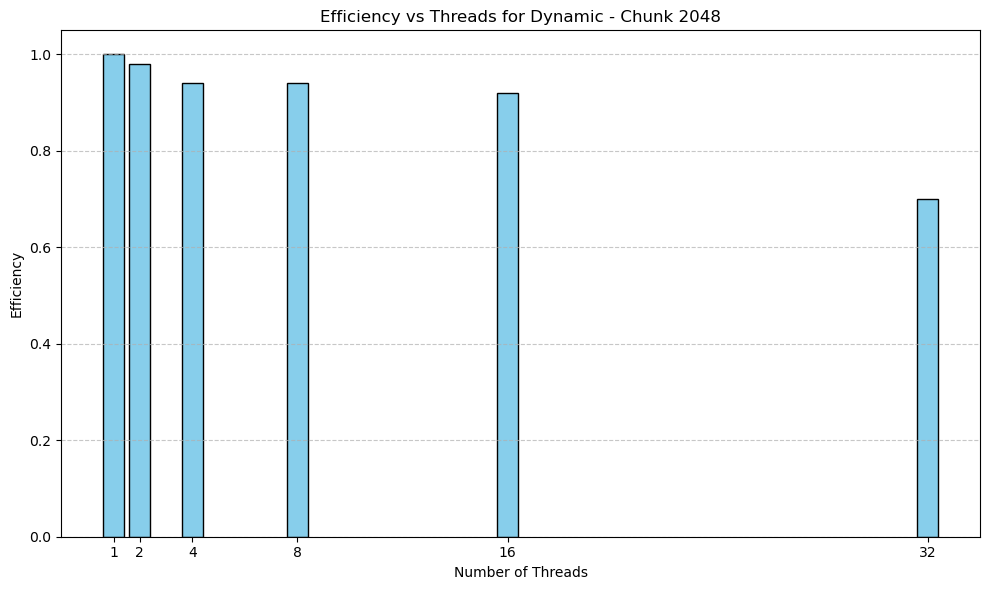

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file using '|' as the delimiter.
# We skip the second line (the dashed separator) using skiprows.
df = pd.read_csv('efficiency.txt', delimiter='|', skiprows=[1], engine='python')

# Remove any leading/trailing whitespace from column names and data
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Convert appropriate columns to numeric types
df['Threads'] = pd.to_numeric(df['Threads'])
df['Chunk Size'] = pd.to_numeric(df['Chunk Size'])
df['Parallel Time (s)'] = pd.to_numeric(df['Parallel Time (s)'])
df['Speedup'] = pd.to_numeric(df['Speedup'])
df['Efficiency'] = pd.to_numeric(df['Efficiency'])

# Create the plot
plt.figure(figsize=(12, 8))

# Loop over each scheduling type and chunk size to plot Parallel Time vs Threads
for sched in df['Scheduling Type'].unique():
    sched_df = df[df['Scheduling Type'] == sched]
    for chunk in sorted(sched_df['Chunk Size'].unique()):
        # Filter data for the current chunk size and scheduling type
        sub_df = sched_df[sched_df['Chunk Size'] == chunk]
        label = f"{sched} - Chunk {chunk}"
        plt.plot(sub_df['Threads'], sub_df['Parallel Time (s)'], marker='o', label=label)

plt.xlabel("Number of Threads")
plt.ylabel("Parallel Time (s)")
plt.title("Parallel Runtime vs Threads for Different Chunk Sizes and Scheduling Types")
plt.legend()
plt.grid(True)
plt.tight_layout()
    # Save each graph as a PNG file with chunk size in filename
plt.savefig("times.png")
plt.close()


# Plot efficiencies as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(sub_df['Threads'], sub_df['Efficiency'], color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel("Number of Threads")
plt.ylabel("Efficiency")
plt.title(f"Efficiency vs Threads for {label}")
plt.xticks(sub_df['Threads'])  # Ensure all thread counts are shown on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined